# Базова регресія
Регресія (або регресійний аналіз) - аналіз даних з урахуванням меншої кількості факторів, ніж може бути у даній множині.
Найпростіший варіант - лінійна регресія - проведення по сукупності точок прямої лінії

## Завдання 1
Потрібно побудувати просту модель лінійної регресії на одній ознаці й отримати передбачення:

 * Завантажте вбудований датасет про діабет із бібліотеки scikit-learn.
 * Виберіть одну ознаку (наприклад, індекс маси тіла — це ознака з індексом 2).
 * Розділіть дані на навчальну і тестову вибірки (80/20).
 * Побудуйте модель за допомогою класу LinearRegression з sklearn.linear_model.
 * Отримайте передбачення на тестовій вибірці та виведіть перші 10 реальних і передбачених значень поруч.

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
dataset = load_diabetes()
#print(dataset.DESCR)
diabetes = pd.DataFrame(dataset.data,columns=dataset.feature_names)
diabetes['Target'] = dataset.target
diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
# Виберіть одну ознаку (наприклад, індекс маси тіла – це ознака з індексом 2).
data = diabetes[['bmi', 'Target']]
data.head()

,bmi,Target
0,0.061696,151.0
1,-0.051474,75.0
2,0.044451,141.0
3,-0.011595,206.0
4,-0.036385,135.0


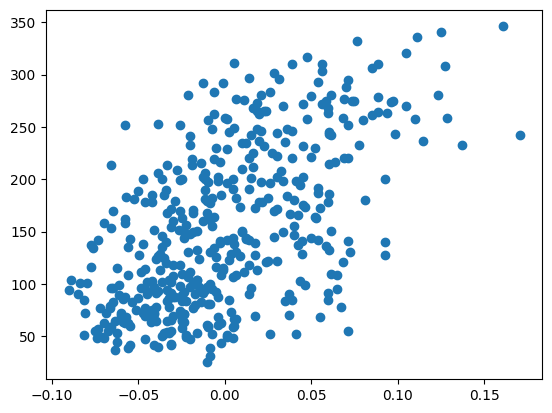

In [ ]:
# Побудуємо графік досліджуваних даних
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(data['bmi'], data['Target'], 'o')
plt.show()

In [ ]:
# Розділіть дані на навчальну і тестову вибірки (80/20).
from sklearn.model_selection import train_test_split
# Моделі регресії зазвичай працюють з множинами вхідних даних, а не лише з одним з них
# тому навіть при одному параметрі його слід подавати як множину (list) з однією величиною [1,2,3] -> [[1],[2],[3]]
xtrain, xtest, ytrain, ytest = train_test_split(
    data['bmi'].array.reshape(-1, 1),   # [1,2,3] -> [[1],[2],[3]]
    data['Target'].array,
    test_size = 0.2,
    random_state = 0)
print(f"Розмірність навчальної послідовності: {len(xtrain)}, тестової: {len(xtest)}")

''' Якість моделі (регресії) оцінюють за передбаченнями, зробленими для тестової
вибірки: увесь масив даних поділяють на навчальний та тестовий (можна сказати, що
з даних вилучають деяку частину, яка буде вживатись як тести). Вилучення має бути
випадковим, з різних частин діапазону даних і невеликого розміру, щоб не погіршувати
процес навчання. Усе це регулюється функцією train_test_split
'''

Розмірність навчальної послідовності: 353, тестової: 89


' Якість моделі (регресії) оцінюють за передбаченнями, зробленими для тестової\nвибірки: увесь масив даних поділяють на навчальний та тестовий (можна сказати, що\nз даних вилучають деяку частину, яка буде вживатись як тести). Вилучення має бути\nвипадковим, з різних частин діапазону даних і невеликого розміру, щоб не погіршувати\nпроцес навчання. Усе це регулюється функцією train_test_split\n'

In [ ]:
# Побудуйте модель за допомогою класу LinearRegression з sklearn.linear_model.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# Отримайте передбачення на тестовій вибірці та виведіть перші 10 реальних і передбачених значень поруч.
# 1. Навчаємо модель та тренувальній вибірці
model.fit(xtrain, ytrain)
# 2. Контролюємо отримані коефіцєнти моделі (регресії)
print(f"Для формули y = ax + b, маємо: a={model.coef_[0]}, b={model.intercept_}")
# 3. Отримаємо від моделі передбачення для тестової вибірки
ypred = model.predict(xtest)
for i in range(10):
    x = xtrain[i][0]
    print(f"x={x}, дійсне значення {ytest[i]}, передбачене значення {ypred[i]}, контроль: {model.coef_[0] * x + model.intercept_}")

Для формули y = ax + b, маємо: a=981.6554361411928, b=152.28824927379569
x=0.002416542455239321, дійсне значення 321.0, передбачене значення 255.17426905069883, контроль: 154.66046131164734
x=-0.07734155101193986, дійсне значення 215.0, передбачене значення 211.79462571068711, контроль: 76.36549528333354
x=-0.035306880130588664, дійсне значення 127.0, передбачене значення 161.00870180042952, контроль: 117.62905846041787
x=0.0013387303813585058, дійсне значення 64.0, передбачене значення 129.26749935651853, контроль: 153.60242123018364
x=0.020739347711212906, дійсне значення 175.0, передбачене значення 196.98206457019535, контроль: 172.64714269653024
x=-0.03638469220446948, дійсне значення 275.0, передбачене значення 247.7679884804529, контроль: 116.57101837895414
x=-0.040695940499992665, дійсне значення 179.0, передбачене значення 123.97729894920003, контроль: 112.33885805309936
x=0.032595280523901676, дійсне значення 232.0, передбачене значення 174.76322285945764, контроль: 184.285583

## Завдання 2
Необхідно візуально показати, як модель описує дані:

 * Використовуйте ті самі дані та модель, що в завданні 1.
 * Побудуйте scatter-графік: по осі X — значення ознаки, по осі Y — реальні значення цільової змінної.
 * Поверх точок побудуйте пряму регресії (передбачення моделі).
 * Додайте підписи осей і легенду.



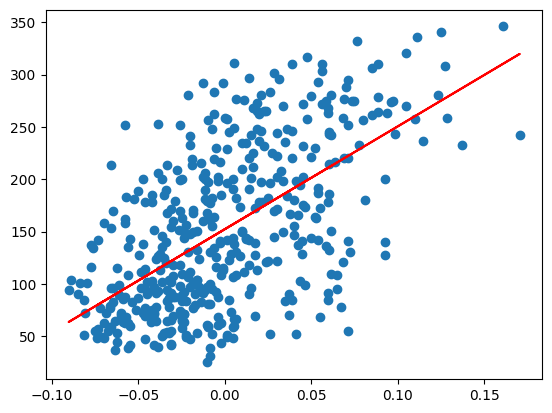

In [ ]:
fig, ax = plt.subplots()
ax.plot(data['bmi'], data['Target'], 'o')
ax.plot(data['bmi'], model.predict(data['bmi'].array.reshape(-1, 1)), 'r-')
plt.show()

## Завдання 3
Потрібно виміряти якість побудованої моделі за допомогою метрик регресії:

 * Використовуйте тестову вибірку із завдання 1.

 * Обчисліть метрики за допомогою функцій з sklearn.metrics:

    - mean_absolute_error — MAE (Mean Absolute Error);

    - mean_squared_error — MSE (Mean Squared Error);

    - r2_score — R² (коефіцієнт детермінації).

 * Оформіть результати в таблиці:



In [ ]:
import sklearn.metrics as sm
from IPython.display import Markdown as md

md("|Метрика|Значення|\n" +
"|-|-|\n|" +
"MAE (Mean Absolute Error)|%f|\n" +
"|MSE (Mean Squared Error)|%f|\n" +
"|R² (коефіцієнт детермінації)|%f|" % (
    1,
    1,
    1
))

|Метрика|Значення|
|-|-|
|MAE (Mean Absolute Error)|1.000000|
|MSE (Mean Squared Error)|1.000000|
|R² (коефіцієнт детермінації)|1.000000|